In [75]:
import sys
import os

# Get the absolute path to the .src directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

In [76]:
DEVICE = 1
SEED = 42

In [77]:
import torch
torch.random.manual_seed(SEED)
selected_labels = torch.arange(344)[torch.randperm(344)][:10]
selected_points = torch.randperm(2500)[:100]
subsampled_labels = selected_labels.repeat_interleave(100).numpy()

In [78]:
import torch
from src.data import QuickDrawDataset

dataset = QuickDrawDataset("../../sketch_representations/data/quickdraw", split="test")
test_loader = torch.utils.data.DataLoader(dataset, batch_size=512, collate_fn=QuickDrawDataset.collate_fn_padd, 
                                           num_workers=8)

In [ ]:
import pickle as pkl
from sklearn.manifold import TSNE
from src.lightning_models import LtSketchReconstruction
from src.models import Sketchformer, BlockConfig, PosEmbeddingConfig
from src.data import InputHandler, OutputHandler

projs = {k: {} for k in ["nar", "nar-enc", "ffn"]}

for decoder_type in ["nar", "nar-enc", "ffn"]:
    for coord_type in ["rel_rel", "rel_abs", "abs_rel", "abs_abs"]:
        with open(f"../../sketch_representations/results/experiment2/{coord_type}_{decoder_type}_{SEED}.pkl", "rb") as file:
            results = pkl.load(file)

        checkpoint = torch.load(f"../../sketch_representations/checkpoints/experiment2/{coord_type}_{decoder_type}_{SEED}/best.ckpt")

        sketchformer = Sketchformer(
            hidden_dim=results['args']['hidden_dim'],
            num_encoder_layers=results['args']['num_encoder_layers'],
            num_decoder_layers=results['args']['num_decoder_layers'],
            decoder_type=results['args']['decoder_type'],
            block_config=BlockConfig(
                dropout=results['args']['hidden_dropout']
            ),
            pos_embedding_config=PosEmbeddingConfig(
                pen_state=results['args']['pen_state'], 
                stroke_embedding=results['args']['stroke_embedding'], 
                sketch_pos=results['args']['sketch_pos'],
                stroke_pos=results['args']['stroke_pos']
            )
        )


        input_handler = InputHandler(input_relative_coords=results['args']['input_relative_coords'], output_relative_coords=results['args']['output_relative_coords'], autoencoder=True, autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"])
        output_handler = OutputHandler(output_relative_coords=results['args']['output_relative_coords'], autoregressive=results['args']['decoder_type'] in ["ar", "ar-enc"])
        model = LtSketchReconstruction(sketchformer, input_handler, output_handler, results['args']['lr'])
        model.load_state_dict(checkpoint['state_dict'])
        model.eval()
        model = model.to("cuda:1")
        sketchformer = model.sketchformer
        sketchformer.decoder = None
        sketchformer.ln_decoder = None

        embeddings = {int(label): [] for label in selected_labels}

        for batch in test_loader:
            batch = {k: v.to("cuda:1") for k,v in batch.items()}
            model_input = input_handler(batch)
            x_enc = model_input['encoder']
            
            with torch.no_grad():
                h_sketch = sketchformer.encode(x_enc['pos'], x_enc['pos_info'], x_enc['token_id'], x_enc['mask'])

            for label in selected_labels:
                if (batch['label'] == label).sum() == 0: continue
                embeddings[int(label)].append(h_sketch[batch['label'] == label].cpu())


        subsampled_embeddings = torch.cat([torch.cat(embeddings[int(label)], dim=0)[selected_points] for label in selected_labels], dim=0)
        projs[decoder_type][coord_type] = TSNE(random_state=SEED).fit_transform(subsampled_embeddings)

torch.save(projs, "../embeddings_projs.pt")

In [91]:
projs = torch.load("../embeddings_projs.pt", weights_only=False)

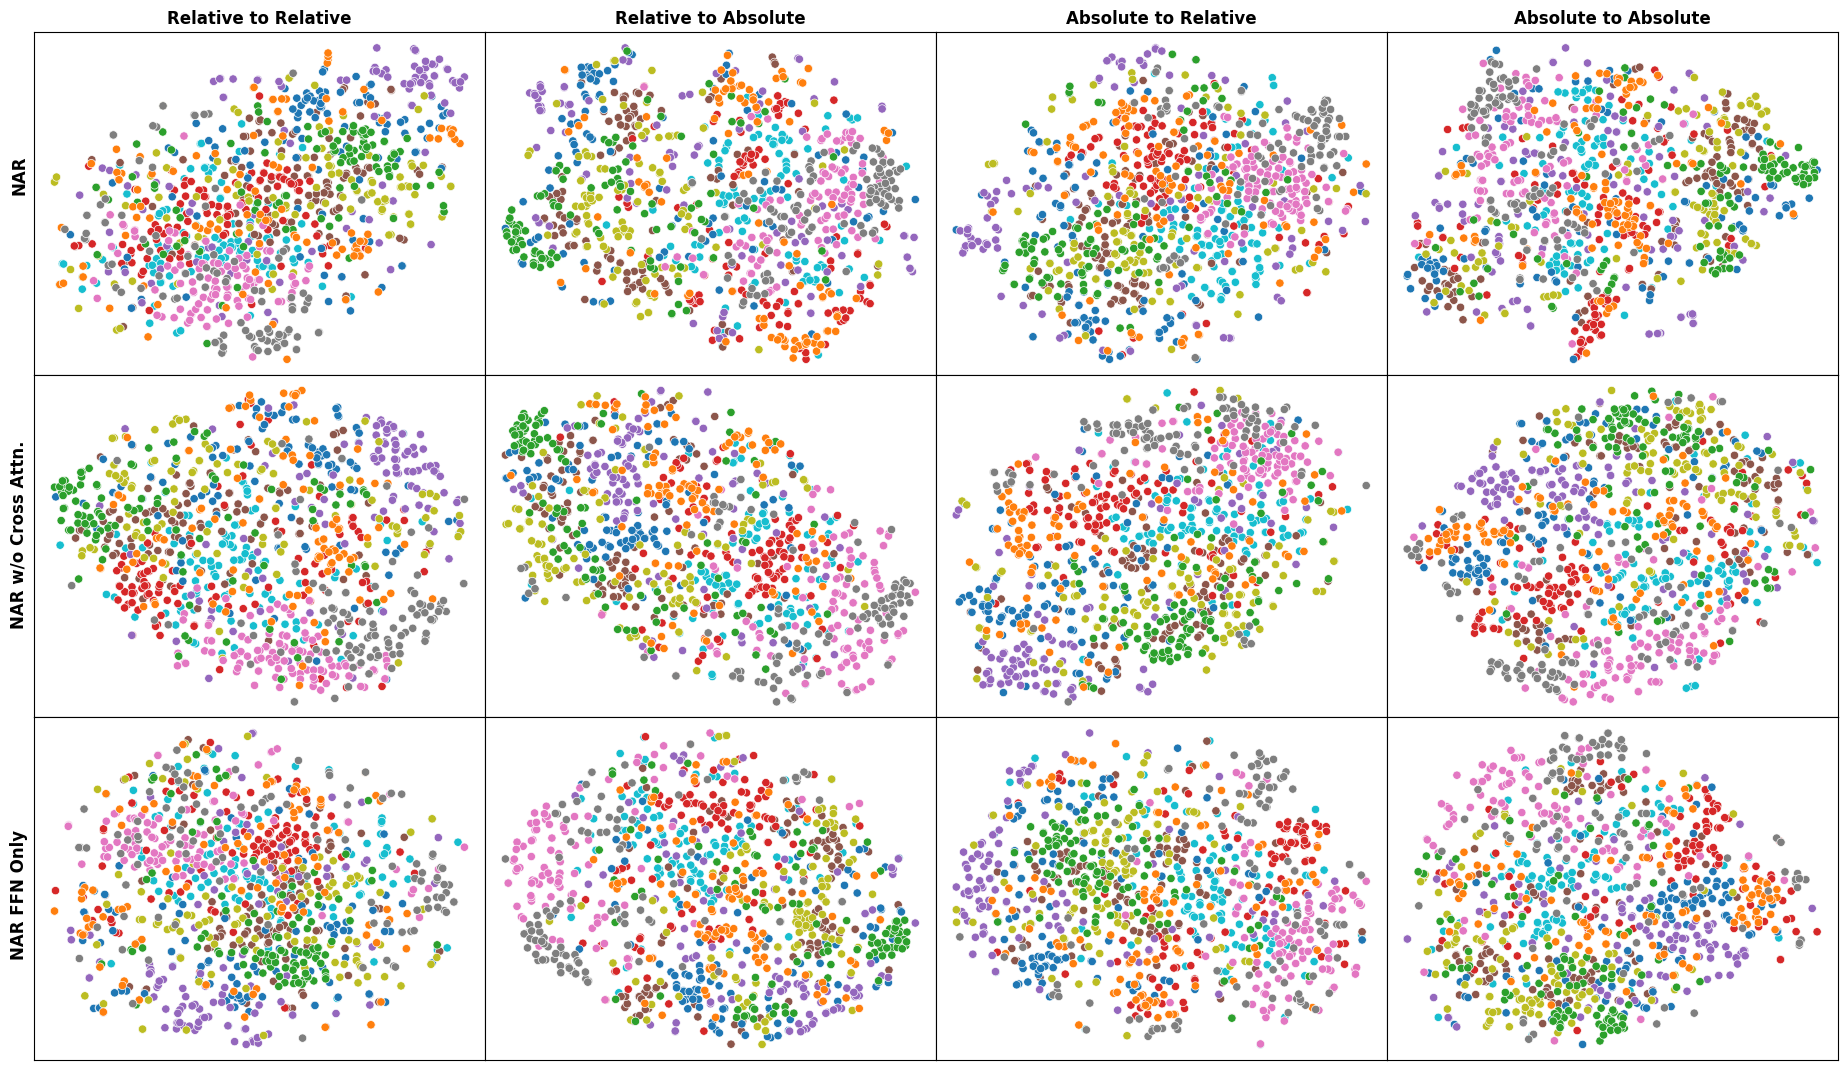

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots (2 rows, 3 columns for example)
fig, axs = plt.subplots(3, 4, figsize=(6.4 * 4 * 0.75, 4.8 * 3 * 0.75))

decoder_types = [('nar', 'NAR'), ('nar-enc', 'NAR w/o Cross Attn.'), ('ffn', 'NAR FFN Only')] 
coord_types = [("rel_rel", "Relative to Relative"), ("rel_abs", "Relative to Absolute"), ("abs_rel","Absolute to Relative"), ("abs_abs", "Absolute to Absolute")]

for i in range(3):
    for j in range(4):
        if i == 0:
            axs[i, j].set_title(coord_types[j][1], fontsize=12, fontweight="bold")
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        sns.scatterplot(x=projs[decoder_types[i][0]][coord_types[j][0]][:, 0], y=projs[decoder_types[i][0]][coord_types[j][0]][:, 1], hue=subsampled_labels, ax=axs[i, j], palette="tab10", legend=False)

for i, decoder_type in enumerate(decoder_types):
    # Place text in figure coordinates (x=0.01, y at center of each row)
    fig.text(0.045, 5/6 - i * 1/3, decoder_type[1], va='center', ha='center',
             rotation='vertical', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0.045, 0, 1, 1])  # Leave space on the left
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()